# Out-of-Distribution (OOD) Detection Using IVON
This notebook contains experiments for evaluating IVON on out-of-distribution detection, by querying the models' certainty on examples seen and not seen during training.

In [9]:
# Install dependencies
!pip install -r requirements.txt

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.datasets import SVHN
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc
import sys

# Use OmegaConf to define hyperparameter configs
from omegaconf import OmegaConf, DictConfig

# Pretty progress bars
from tqdm import tqdm

# Import functionality for loading model checkpoints, initializing optimizers etc
from utils import load_checkpoint, init_model, init_optimizer, load_dataset

# Import training script
from train import train


In [2]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

Using device: cuda:0


In [3]:
print("Python version:")
print(sys.version)

print("\nPyTorch version:")
print(torch.__version__)

Python version:
3.12.3 (main, Nov  6 2025, 13:44:16) [GCC 13.3.0]

PyTorch version:
2.9.1+cu128


## Load CIFAR-10

In [4]:
train_set, val_set, test_set = load_dataset(name="cifar10", train_ratio=0.9, root="data", seed=42)

# --- DataLoaders (batch_size = 50 to match IVON paper) ---
train_loader = torch.utils.data.DataLoader(train_set, batch_size=50, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_set,   batch_size=50, shuffle=False)
test_loader  = torch.utils.data.DataLoader(test_set,  batch_size=50, shuffle=False)

## Out-of-Distribution and In-Between Uncertainty Evaluation
In the next cell, we evaluate the model on **SVHN**, which serves as an out-of-distribution dataset relative to CIFAR-10.
This reproduces the paper’s OOD uncertainty results—corresponding to **Figure 3(a)** and the detection metrics reported in **Table 3**.
Moreover, we are going to test **class exclusion**, where specific CIFAR-10 classes are withheld during training to further examine the model’s uncertainty under intentional distribution gaps.
Here we again use the same OOD uncertainty metrics to evaluate how effectively the model identifies excluded classes as uncertain.

Subtask: Load the SVHN test dataset and apply the same normalization as CIFAR-10, then create a PyTorch DataLoader for the SVHN test set to be used as an Out-of-Distribution dataset.

In [10]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

transform_svhn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std), # Re-using CIFAR-10 mean and std
])

# Load the SVHN test dataset
svhn_dataset = SVHN(
    root='./data',
    split='test',
    transform=transform_svhn,
    download=True
)

# Create a DataLoader for the SVHN test dataset
svhn_loader = torch.utils.data.DataLoader(
    svhn_dataset,
    batch_size=50,
    shuffle=False
)

print("SVHN test dataset loaded and DataLoader created.")

SVHN test dataset loaded and DataLoader created.


### Class-Exclusion Experiment Pipeline

The following three code cells implement a full **class-exclusion uncertainty experiment** on CIFAR-10 using the IVON optimizer. First, we build custom datasets using `ExcludedClassDataset`, which filters out selected classes (e.g., *airplane* and *automobile*) from training while creating separate test sets for included and excluded classes. Second, we construct DataLoaders for these splits and train a ResNet-20 model **only on the remaining CIFAR-10 classes**, ensuring the excluded classes are completely unseen during training. Finally, we evaluate the trained model by computing predictive entropy via Monte Carlo sampling on three datasets—**included CIFAR-10 classes**, **excluded CIFAR-10 classes**, and **SVHN**—and generate uncertainty plots and OOD-style metrics to compare how the model behaves on seen, unseen, and external data.


In [5]:
# Define CIFAR-10 class_names
cifar10_class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'
]

# Create a custom PyTorch Dataset class called ExcludedClassDataset
class FilteredClassDataset(Dataset):
    def __init__(self, original_dataset, excluded_classes_by_name, return_excluded=False):
        self.original_dataset = original_dataset
        self.return_excluded = return_excluded

        # Build class-name → index mapping
        self.class_to_idx = {name: i for i, name in enumerate(cifar10_class_names)}
        self.excluded_class_indices = {self.class_to_idx[name] for name in excluded_classes_by_name}

        # Prefer using targets for speed
        if hasattr(original_dataset, "targets"):
            labels = original_dataset.targets
        else:
            # fallback (slow)
            labels = [original_dataset[i][1] for i in range(len(original_dataset))]

        # Filter indices
        self.filtered_indices = []
        included_labels = set()

        for i, label in enumerate(labels):
            is_excluded = label in self.excluded_class_indices

            if (is_excluded and return_excluded) or (not is_excluded and not return_excluded):
                self.filtered_indices.append(i)
                if not return_excluded:
                    included_labels.add(label)

        # Build label mapping for included classes
        self.label_mapping = None
        if not return_excluded:
            sorted_labels = sorted(included_labels)
            self.label_mapping = {old: new for new, old in enumerate(sorted_labels)}

    def __len__(self):
        return len(self.filtered_indices)

    def __getitem__(self, idx):
        original_idx = self.filtered_indices[idx]
        img, label = self.original_dataset[original_idx]

        if self.label_mapping:
            label = self.label_mapping[label]

        return img, label


In [6]:
# ============================================================
# Part 1 — Create datasets for class exclusion setup
# ============================================================

# These classes will be removed from training,
# but they are still normal CIFAR-10 classes (NOT real OOD).
excluded_classes_for_ood = ['airplane', 'automobile']

print("Preparing datasets using ExcludedClassDataset...")
print(f"Excluded classes: {excluded_classes_for_ood}")
print("-" * 60)

# ------------------------------------------------------------
# Training set containing ONLY the included (non-excluded) classes
# ------------------------------------------------------------
cifar10_train_included = FilteredClassDataset(
    train_set,
    excluded_classes_by_name=excluded_classes_for_ood,
    return_excluded=False
)

print(f"[TRAIN INCLUDED] CIFAR-10 training data (excluded {', '.join(excluded_classes_for_ood)}): "
      f"{len(cifar10_train_included)} samples")

# ------------------------------------------------------------
# Test set containing ONLY the excluded classes
# (these are “class-OOD”, not true OOD)
# ------------------------------------------------------------
cifar10_test_excluded = FilteredClassDataset(
    test_set,
    excluded_classes_by_name=excluded_classes_for_ood,
    return_excluded=True
)

print(f"[TEST OOD] CIFAR-10 test data (only {', '.join(excluded_classes_for_ood)}): "
      f"{len(cifar10_test_excluded)} samples")

# ------------------------------------------------------------
# Test set containing ONLY the included (training) classes
# ------------------------------------------------------------
cifar10_test_included = FilteredClassDataset(
    test_set,
    excluded_classes_by_name=excluded_classes_for_ood,
    return_excluded=False
)

print(f"[TEST INCLUDED] CIFAR-10 test data (included classes only): "
      f"{len(cifar10_test_included)} samples")
print("-" * 60)


Preparing datasets using ExcludedClassDataset...
Excluded classes: ['airplane', 'automobile']
------------------------------------------------------------
[TRAIN INCLUDED] CIFAR-10 training data (excluded airplane, automobile): 36000 samples
[TEST OOD] CIFAR-10 test data (only airplane, automobile): 2000 samples
[TEST INCLUDED] CIFAR-10 test data (included classes only): 8000 samples
------------------------------------------------------------


In [7]:
# ============================================================
# Part 2 — Create DataLoaders 
# ============================================================

batch_size = 50
print(f"Creating DataLoaders (batch size = {batch_size})...")

# Training loader (included classes)
cifar10_train_included_loader = DataLoader(
    cifar10_train_included,
    batch_size=batch_size,
    shuffle=True
)
print("✔ DataLoader for TRAIN INCLUDED classes created.")

# Test loader (excluded classes — class-OOD)
cifar10_test_excluded_loader = DataLoader(
    cifar10_test_excluded,
    batch_size=batch_size,
    shuffle=False
)
print("✔ DataLoader for TEST EXCLUDED (OOD) classes created.")

# Test loader (included classes — in-domain)
cifar10_test_included_loader = DataLoader(
    cifar10_test_included,
    batch_size=batch_size,
    shuffle=False
)
print("✔ DataLoader for TEST INCLUDED (normal test) classes created.")
print("-" * 60)



Creating DataLoaders (batch size = 50)...
✔ DataLoader for TRAIN INCLUDED classes created.
✔ DataLoader for TEST EXCLUDED (OOD) classes created.
✔ DataLoader for TEST INCLUDED (normal test) classes created.
------------------------------------------------------------


## Train IVON

Training IVON with config:

lr: 0.2
batch: 50
epochs: 200
warmup_epochs: 5
optim:
  n_samples: 1
  lambda_: 36000
  h0: 0.5
  beta1: 0.9
  beta2: 0.99999
  weight_decay: 0.0002
n_classes: 10


Epoch 0; train_loss=1.464
Saving checkpoint to 'checkpoints/cifar10_excluded/resnet20__ivon__1.pt' ...
Epoch 1; train_loss=1.141
Saving checkpoint to 'checkpoints/cifar10_excluded/resnet20__ivon__2.pt' ...
Epoch 2; train_loss=0.9729
Epoch 3; train_loss=0.8607
Epoch 4; train_loss=0.7673
Saving checkpoint to 'checkpoints/cifar10_excluded/resnet20__ivon__5.pt' ...
Epoch 5; train_loss=0.6978
Epoch 6; train_loss=0.6202
Epoch 7; train_loss=0.5776
Epoch 8; train_loss=0.5328
Epoch 9; train_loss=0.5107
Saving checkpoint to 'checkpoints/cifar10_excluded/resnet20__ivon__10.pt' ...
Epoch 10; train_loss=0.4744
Epoch 11; train_loss=0.4599
Epoch 12; train_loss=0.4371
Epoch 13; train_loss=0.4208
Epoch 14; train_loss=0.4089
Epoch 15; train_loss=0.4025
Epoch 16; train_loss=0.3924
Epoch 17; train_loss=0.377
Epoch 1

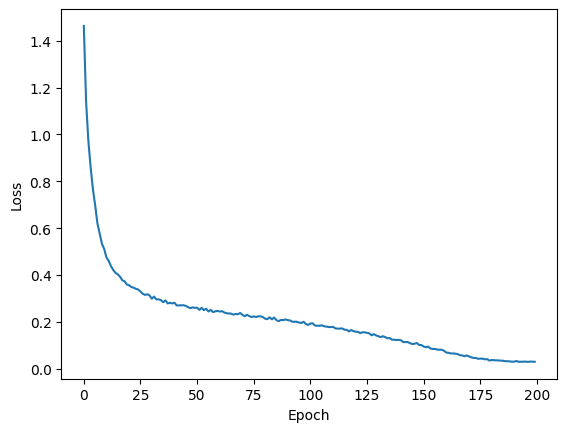

In [20]:
# Get hyperparam config
config = OmegaConf.load("configs/cifar10__ivon.yaml")
# Update lambda parameter
config.optim.update({"lambda_": len(cifar10_train_included)})
print("Training IVON with config:", OmegaConf.to_yaml(config), sep="\n\n", end="\n\n")

# Initialize model and optimizer
model_ivon_excluded = init_model("resnet20", n_classes=10)
model_ivon_excluded.to(device)
optimizer_ivon_excluded = init_optimizer(model_ivon_excluded, "ivon", config)

# Do the training
train_losses, _ = train(dataset_name="cifar10_excluded", 
      model_name="resnet20",
      model=model_ivon_excluded,
      optimizer=optimizer_ivon_excluded, 
      train_loader=cifar10_train_included_loader,
      config=config
)
plt.plot(train_losses, label="Train loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Train SGD

Training SGD with config:

lr: 0.1
batch: 50
epochs: 200
warmup_epochs: 5
optim:
  beta1: 0.9
  weight_decay: 0.0002
n_classes: 10


Epoch 0; train_loss=1.489
Saving checkpoint to 'checkpoints/cifar10_excluded/resnet20__sgd__1.pt' ...
Epoch 1; train_loss=1.14
Saving checkpoint to 'checkpoints/cifar10_excluded/resnet20__sgd__2.pt' ...
Epoch 2; train_loss=0.9722
Epoch 3; train_loss=0.8328
Epoch 4; train_loss=0.7539
Saving checkpoint to 'checkpoints/cifar10_excluded/resnet20__sgd__5.pt' ...
Epoch 5; train_loss=0.7099
Epoch 6; train_loss=0.6498
Epoch 7; train_loss=0.6195
Epoch 8; train_loss=0.5933
Epoch 9; train_loss=0.5741
Saving checkpoint to 'checkpoints/cifar10_excluded/resnet20__sgd__10.pt' ...
Epoch 10; train_loss=0.5601
Epoch 11; train_loss=0.5444
Epoch 12; train_loss=0.5334
Epoch 13; train_loss=0.5166
Epoch 14; train_loss=0.513
Epoch 15; train_loss=0.5028
Epoch 16; train_loss=0.5019
Epoch 17; train_loss=0.4835
Epoch 18; train_loss=0.4819
Epoch 19; train_loss=0.4768
Epoch 20; train_

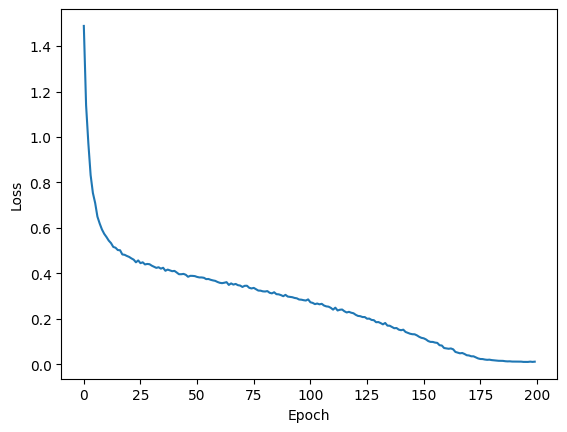

In [15]:
# Get hyperparam config
config = OmegaConf.load("configs/cifar10__sgd.yaml")
print("Training SGD with config:", OmegaConf.to_yaml(config), sep="\n\n", end="\n\n")

# Initialize model and optimizer
model_sgd_excluded = init_model("resnet20", n_classes=10)
model_sgd_excluded.to(device)
optimizer_sgd_excluded = init_optimizer(model_sgd_excluded, "sgd", config)

# Do the training
train_losses, _ = train(dataset_name="cifar10_excluded", 
      model_name="resnet20",
      model=model_sgd_excluded,
      optimizer=optimizer_sgd_excluded, 
      train_loader=cifar10_train_included_loader,
      config=config
)
plt.plot(train_losses, label="Train loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Load Checkpoints

In [8]:
# Run this cell to load checkpoints trained previously
model_ivon_excluded, optimizer_ivon_excluded, _config = load_checkpoint(
    optimizer_name="ivon", 
    dataset_name="cifar10_excluded", 
    model_name="resnet20", 
    epoch=200,
    device=device
)
model_sgd_excluded, optimizer_sgd_excluded, _config = load_checkpoint(
    optimizer_name="sgd", 
    dataset_name="cifar10_excluded", 
    model_name="resnet20", 
    epoch=200,
    device=device
)

Loaded config: {'lr': 0.2, 'batch': 50, 'epochs': 200, 'warmup_epochs': 5, 'optim': {'n_samples': 1, 'lambda_': 36000, 'h0': 0.5, 'beta1': 0.9, 'beta2': 0.99999, 'weight_decay': 0.0002}, 'n_classes': 10}
Loaded config: {'lr': 0.1, 'batch': 50, 'epochs': 200, 'warmup_epochs': 5, 'optim': {'beta1': 0.9, 'weight_decay': 0.0002}, 'n_classes': 10}


## Evaluation

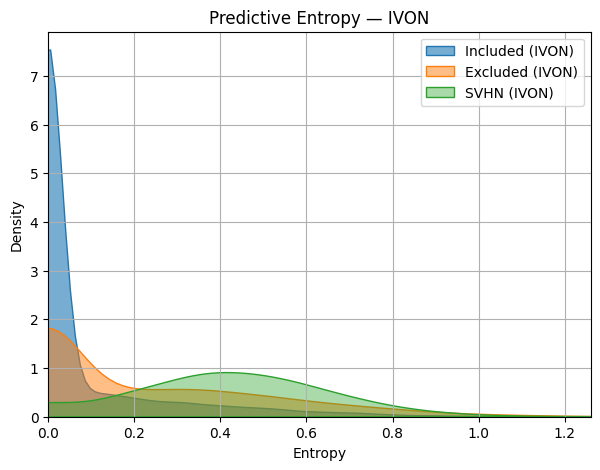

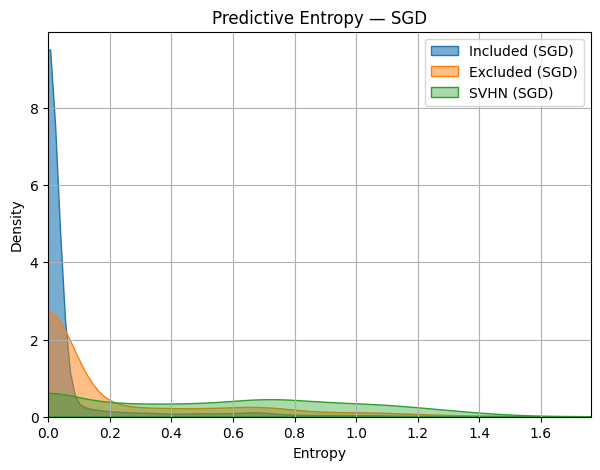

In [15]:
# ==============================================================
# Part 3 — Predictive Entropy, KDE Plots, and Unified Metrics
# ==============================================================

# --------------------------------------------------------------
# a1. Predictive Entropy Functions
# --------------------------------------------------------------

# IVON entropy (uses optimizer.sampled_params)
def predictive_entropy(logits_mc):
    probs = logits_mc.softmax(dim=-1)
    entropy_per_sample = -(probs * (probs + 1e-12).log()).sum(dim=-1)  # [S, B]
    return entropy_per_sample.mean(dim=0).cpu().numpy()                # [B]


def get_entropy_ivon(model, optimizer, loader, mc_samples=5):
    model.eval()
    all_entropies = []

    with torch.no_grad():
        for X, _ in loader:
            X = X.to(device)

            logits_list = []
            for _ in range(mc_samples):
                with optimizer.sampled_params(train=False):
                    logits_list.append(model(X))

            logits_mc = torch.stack(logits_list, dim=0)   # [S, B, C]
            entropy = predictive_entropy(logits_mc)
            all_entropies.append(entropy)

    return np.concatenate(all_entropies)  # [N]


# SGD entropy (deterministic forward pass)
def get_entropy_sgd(model, loader):
    model.eval()
    all_entropies = []

    with torch.no_grad():
        for X, _ in loader:
            X = X.to(device)
            logits = model(X)
            probs = logits.softmax(dim=-1)
            entropy = -(probs * (probs + 1e-12).log()).sum(dim=-1)  # [B]
            all_entropies.append(entropy.cpu().numpy())

    return np.concatenate(all_entropies)


# --------------------------------------------------------------
# a2. Compute All Entropies (IVON & SGD)
# --------------------------------------------------------------

# ---- IVON ----
entropy_included_ivon = get_entropy_ivon(model_ivon_excluded, optimizer_ivon_excluded, cifar10_test_included_loader)
entropy_excluded_ivon = get_entropy_ivon(model_ivon_excluded, optimizer_ivon_excluded, cifar10_test_excluded_loader)
entropy_svhn_ivon     = get_entropy_ivon(model_ivon_excluded, optimizer_ivon_excluded, svhn_loader)

# ---- SGD ----
entropy_included_sgd = get_entropy_sgd(model_sgd_excluded, cifar10_test_included_loader)
entropy_excluded_sgd = get_entropy_sgd(model_sgd_excluded, cifar10_test_excluded_loader)
entropy_svhn_sgd     = get_entropy_sgd(model_sgd_excluded, svhn_loader)


# --------------------------------------------------------------
# a3. KDE Plots — One for IVON, One for SGD
# --------------------------------------------------------------

def positive_kde(data, **kwargs):
    """Makes a KDE plot where negative values have zero density."""
    data = np.concatenate((data, -data), axis=0)
    sns.kdeplot(data, **kwargs)
    plt.xlim([0, None])


# ---- Plot IVON ----
plt.figure(figsize=(7,5))
positive_kde(entropy_included_ivon, fill=True, label="Included (IVON)", alpha=0.6)
positive_kde(entropy_excluded_ivon, fill=True, label="Excluded (IVON)", alpha=0.5)
positive_kde(entropy_svhn_ivon,     fill=True, label="SVHN (IVON)", alpha=0.4)
plt.title("Predictive Entropy — IVON")
plt.xlabel("Entropy")
plt.legend()
plt.grid(True)
plt.show()


# ---- Plot SGD ----
plt.figure(figsize=(7,5))
positive_kde(entropy_included_sgd, fill=True, label="Included (SGD)", alpha=0.6)
positive_kde(entropy_excluded_sgd, fill=True, label="Excluded (SGD)", alpha=0.5)
positive_kde(entropy_svhn_sgd,     fill=True, label="SVHN (SGD)", alpha=0.4)
plt.title("Predictive Entropy — SGD")
plt.xlabel("Entropy")
plt.legend()
plt.grid(True)
plt.show()


## OOD Detection Metrics

---

### **AUROC — Area Under the ROC Curve**
Measures how well the score separates ID vs. OOD samples.

$$
\text{AUROC} = \int_{0}^{1} \text{TPR}(\text{FPR}) \, d\text{FPR}
$$

Equivalent interpretation:

$$
\text{AUROC} = \Pr\big(s_{\text{ood}} > s_{\text{in}}\big)
$$

Higher is better.

---

### **FPR@95 — False Positive Rate at 95% TPR**
False positive rate when the true positive rate for OOD detection is 95%.

Find threshold $ f^* $ such that:

$$
\text{TPR}(f^*) \approx 0.95
$$

Then report:

$$
\text{FPR@95} = \text{FPR}(f^*)
$$

Lower is better.

---

### **Detection Error**
Minimum classification error assuming equal priors for ID and OOD.

$$
\text{Detection Error}
= \min_f \left[ 0.5 \cdot \text{FPR}(f) + 0.5 \cdot \text{FNR}(f) \right]
$$

where

$$
\text{FNR}(f) = 1 - \text{TPR}(f)
$$

Lower is better.

---

### **AUPR-In — Area Under Precision–Recall (ID as Positive Class)**
Precision–Recall AUC with **ID = positive**.

$$
\text{AUPR-In} = \int_0^1 \text{Precision}_{\text{in}}(r) \, dr
$$

Higher means better ID recognition.

---

### **AUPR-Out — Area Under Precision–Recall (OOD as Positive Class)**
Precision–Recall AUC with **OOD = positive**.

$$
\text{AUPR-Out} = \int_0^1 \text{Precision}_{\text{out}}(r) \, dr
$$

Higher means better OOD detection.

---


In [25]:
# --------------------------------------------------------------
# b1. Metrics
# --------------------------------------------------------------
def compute_fpr95(scores_in, scores_ood):
    labels = np.concatenate([np.zeros_like(scores_in), np.ones_like(scores_ood)])
    scores = np.concatenate([scores_in, scores_ood])
    fprs, tprs, thresholds = roc_curve(labels, scores)
    idx = np.argmin(np.abs(tprs - 95/100))
    return fprs[idx]


def compute_detection_error(scores_in, scores_ood):
    labels = np.concatenate([np.zeros_like(scores_in), np.ones_like(scores_ood)])
    scores = np.concatenate([scores_in, scores_ood])
    fprs, tprs, _ = roc_curve(labels, scores)
    fnrs = 1 - tprs
    return np.min(0.5 * (fnrs + fprs))


def compute_aupr(scores_in, scores_ood):
    labels = np.concatenate([np.zeros_like(scores_in), np.ones_like(scores_ood)])
    scores = np.concatenate([scores_in, scores_ood])

    # AUPR-In (IN is positive class)
    prec_in, rec_in, _ = precision_recall_curve(1 - labels, -scores)
    aupr_in = auc(rec_in, prec_in)

    # AUPR-Out (OOD is positive class)
    prec_out, rec_out, _ = precision_recall_curve(labels, scores)
    aupr_out = auc(rec_out, prec_out)

    return aupr_in, aupr_out



# --------------------------------------------------------------
# b2. Metrics (AUROC, FPR@95, Detection Error, AUPR)
# --------------------------------------------------------------

def collect_metrics(ent_in, ent_ood):
    labels = np.concatenate([np.zeros_like(ent_in), np.ones_like(ent_ood)])
    scores = np.concatenate([ent_in, ent_ood])

    auroc = roc_auc_score(labels, scores)
    fpr95 = compute_fpr95(ent_in, ent_ood)
    det_err = compute_detection_error(ent_in, ent_ood)
    aupr_in, aupr_out = compute_aupr(ent_in, ent_ood)

    return auroc, fpr95, det_err, aupr_in, aupr_out



# --------------------------------------------------------------
# b3. Unified Comparison Table — IVON vs SGD
# --------------------------------------------------------------

rows = []

datasets = {
    "Excluded CIFAR-10": (
        entropy_excluded_ivon, entropy_excluded_sgd
    ),
    "SVHN": (
        entropy_svhn_ivon, entropy_svhn_sgd
    )
}

for name, (ent_ood_ivon, ent_ood_sgd) in datasets.items():
    metrics_ivon = collect_metrics(entropy_included_ivon, ent_ood_ivon)
    metrics_sgd  = collect_metrics(entropy_included_sgd,  ent_ood_sgd)

    rows.append({
        "Dataset": name,
        "IVON_AUROC":     metrics_ivon[0],
        "SGD_AUROC":      metrics_sgd[0],
        "IVON_FPR95":     metrics_ivon[1],
        "SGD_FPR95":      metrics_sgd[1],
        "IVON_DetErr":    metrics_ivon[2],
        "SGD_DetErr":     metrics_sgd[2],
        "IVON_AUPR-In":   metrics_ivon[3],
        "SGD_AUPR-In":    metrics_sgd[3],
        "IVON_AUPR-Out":  metrics_ivon[4],
        "SGD_AUPR-Out":   metrics_sgd[4],
    })

df_compare = pd.DataFrame(rows).set_index("Dataset")

print("========== UNIFIED OOD METRICS TABLE (IVON vs SGD) ==========")
display(df_compare.style.format("{:.4f}"))


========== UNIFIED OOD METRICS TABLE (IVON vs SGD) ==========


,IVON_AUROC,SGD_AUROC,IVON_FPR95,SGD_FPR95,IVON_DetErr,SGD_DetErr,IVON_AUPR-In,SGD_AUPR-In,IVON_AUPR-Out,SGD_AUPR-Out
Dataset,,,,,,,,,,
Excluded CIFAR-10,0.7366,0.7438,0.7248,0.7319,0.3235,0.3134,0.9143,0.9181,0.3961,0.3939
SVHN,0.8830,0.9285,0.3166,0.2200,0.1743,0.1334,0.8199,0.8828,0.9406,0.9684
